In [1]:
import matplotlib.pyplot as plt
import numpy as np
import skimage
import scipy
import sklearn.metrics

# IoU Analysis Example

In [18]:
def compare_two_labels(label_model, label_gt, return_IoU_matrix, debug=False):
    
    # get number of detected nuclei
    nb_nuclei_gt = np.max(label_gt)
    nb_nuclei_model = np.max(label_model)
    
    # catch the case of an empty picture in model and gt
    if nb_nuclei_gt == 0 and nb_nuclei_model == 0:
        if(return_IoU_matrix):
            return [0, 0, 1, np.empty(0)]     
        else:
            return [0, 0, 1]
    
    # catch the case of empty picture in model
    if nb_nuclei_model == 0:
        if(return_IoU_matrix):
            return [0, nb_nuclei_gt, 0, np.empty(0)]     
        else:
            return [0, nb_nuclei_gt, 0]
    
    # catch the case of empty picture in gt
    if nb_nuclei_gt == 0:
        if(return_IoU_matrix):
            return [nb_nuclei_model, 0, 0, np.empty(0)]     
        else:
            return [nb_nuclei_model, 0, 0]
    
    # build IoU matrix
    IoUs = np.full((nb_nuclei_gt, nb_nuclei_model), -1.0, dtype = np.float32)

    # calculate IoU for each nucleus index_gt in GT and nucleus index_pred in prediction    
    # TODO improve runtime of this algorithm
    for index_gt in range(1,nb_nuclei_gt+1):

        nucleus_gt = label_gt == index_gt
        number_gt = np.sum(nucleus_gt)

        for index_model in range(1,nb_nuclei_model+1):
            
            if debug:
                print(index_gt, "/", index_model)
            
            nucleus_model = label_model == index_model 
            number_model = np.sum(nucleus_model)
            
            same_and_1 = np.sum((nucleus_gt == nucleus_model) * nucleus_gt)
            
            IoUs[index_gt-1,index_model-1] = same_and_1 / (number_gt + number_model - same_and_1)
    
    # get matches and errors
    detection_map = (IoUs > 0.5)
    nb_matches = np.sum(detection_map)

    detection_rate = IoUs * detection_map
    
    nb_overdetection = nb_nuclei_model - nb_matches
    nb_underdetection = nb_nuclei_gt - nb_matches
    
    mean_IoU = np.mean(np.sum(detection_rate, axis = 1))
    
    if(return_IoU_matrix):
        result = [nb_overdetection, nb_underdetection, mean_IoU, IoUs]
    else:
        result = [nb_overdetection, nb_underdetection, mean_IoU]
    return result


In [3]:
def measures_at(threshold, IOU):
    matches = IOU > threshold
    
    true_positives = np.sum(matches, axis=1) == 1   # Correct objects
    false_positives = np.sum(matches, axis=0) == 0  # Extra objects
    false_negatives = np.sum(matches, axis=1) == 0  # Missed objects
    
    assert np.all(np.less_equal(true_positives, 1))
    assert np.all(np.less_equal(false_positives, 1))
    assert np.all(np.less_equal(false_negatives, 1))
    
    TP, FP, FN = np.sum(true_positives), np.sum(false_positives), np.sum(false_negatives)
    
    f1 = 2*TP / (2*TP + FP + FN + 1e-9)

    prec = TP / (TP + FP)

    rec = TP / (TP + FN)

    return f1, prec, rec, TP, FP, FN

In [4]:
prob = np.load("/Users/jcaicedo/Documents/code/micronuclei-detection/20X_c0-DAPI_A1_Tile-190._probabilities.npy")
gt = skimage.io.imread("~/dataset_v2/20X_c0-DAPI_A1_Tile-190.phenotype_outlines.png")

In [5]:
prob.shape

(2, 2960, 2960)

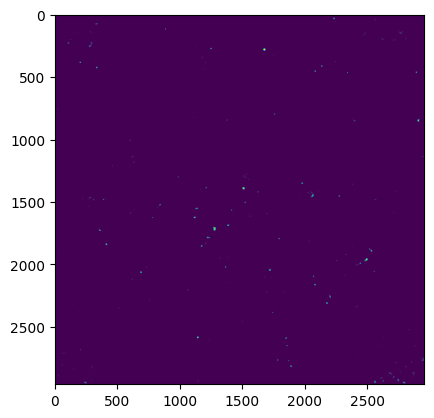

In [6]:
plt.imshow(prob[0,:,:])

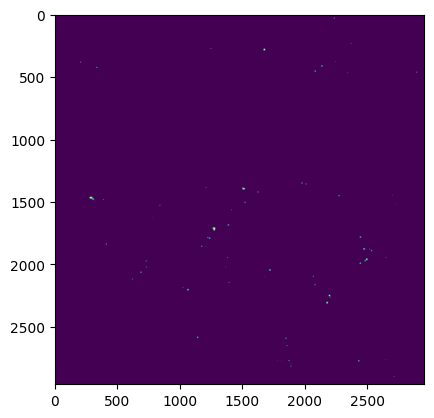

In [7]:
otl = gt[:,:,0] > 0
gt = scipy.ndimage.binary_fill_holes(otl) ^ otl
plt.imshow(gt)

In [8]:
jac = sklearn.metrics.jaccard_score(gt.flatten(), prob[0,:,:].flatten() > 0.5)

In [9]:
pred = prob[0,:,:] > 0.5
np.unique(pred)

array([False,  True])

In [10]:
pi = skimage.morphology.label(pred)
np.unique(pi)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72], dtype=int32)

In [11]:
gti = skimage.morphology.label(gt)
np.unique(gti)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73], dtype=int32)

In [12]:
nb_overdetection, nb_underdetection, mean_IoU, IoUs = compare_two_labels(pi, gti, True)

In [13]:
nb_overdetection, nb_underdetection, mean_IoU

(56, 57, 0.13851525)

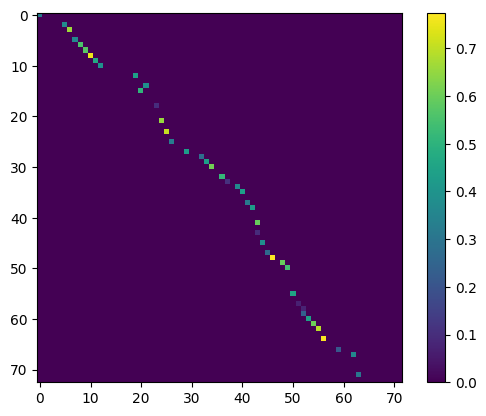

In [17]:
plt.imshow(IoUs)
plt.colorbar()

In [18]:
f1, prec, rec, TP, FP, FN = measures_at(0.1, IoUs)

In [19]:
f1, prec, rec, TP, FP, FN

(0.5655172413754103, 0.5694444444444444, 0.5616438356164384, 41, 31, 32)

# Save 18 Probabilities & IoUs

In [6]:
import os
import sys
sys.path.append('../')
import time
import torch
import skimage
import sklearn.metrics
import wandb

import numpy as np
import matplotlib.pyplot as plt

from microdet import mnds

In [12]:
# Hyperparameters
DIRECTORY = os.pardir + '/microdet' + '/dataset_v2'
OUTPUT_DIR = "/model_output/output/"
SCALE_FACTOR = 1.0
THRESHOLD = 0.5

In [15]:
filelist = os.listdir(DIRECTORY + OUTPUT_DIR)
files = [file for file in filelist if file.endswith('_probabilities.npy')]
print(len(files)) # 18 expected
print(files[15])

18
C2-20X_c0-DAPI-GFP_B2_Tile-20._probabilities.npy


In [8]:
prob = np.load(DIRECTORY + OUTPUT_DIR + files[15])
mn_pred = prob[0,:,:] > THRESHOLD
mn_gt = mnds.read_micronuclei_masks(DIRECTORY, files[15].split('.')[0], SCALE_FACTOR)

pi = skimage.morphology.label(mn_pred)
gti = skimage.morphology.label(mn_gt)
nb_overdetection, nb_underdetection, mean_IoU, IoUs = compare_two_labels(pi, gti, True)

In [9]:
np.unique(pi)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104], dtype=int32)

In [10]:
np.unique(gti)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87], dtype=int32)

In [11]:
print(nb_overdetection, nb_underdetection, mean_IoU)

50 33 0.3840428


In [12]:
print(len(np.unique(gti)),len(np.unique(pi)))
print(IoUs.shape)

88 105
(87, 104)


In [13]:
print(type(IoUs))
print(IoUs)

<class 'numpy.ndarray'>
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.4        0.         0.         ... 0.         0.         0.        ]
 [0.         0.4848485  0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.61538464 0.         0.        ]]


0.8586387434510019 0.7884615384615384


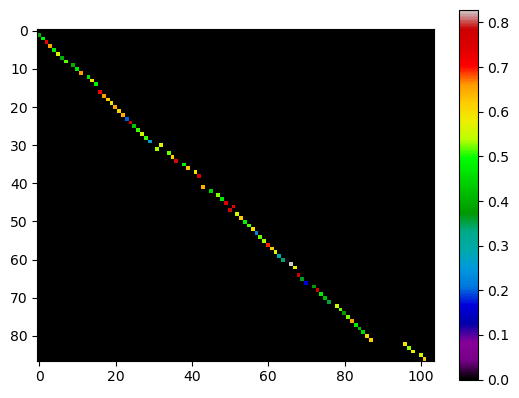

In [14]:
plt.imshow(IoUs, cmap='nipy_spectral') # jet, turbo
plt.colorbar()
f1, prec, rec, TP, FP, FN = measures_at(0.1, IoUs)
print(f1, prec)

## Calulate the area of original size divided by detected size

In [15]:
matches = IoUs > 0.1 # 0.1 threshold for intersection of union
matches

array([[False, False, False, ..., False, False, False],
       [ True, False, False, ..., False, False, False],
       [False,  True, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ...,  True, False, False]])

- Get label correspondence

### Label should be IoU index + 1, label 0 is background which is excluded in IoU matrix

In [17]:
x = np.array([[1,2,1],[3,4,4]])
print(np.sum(x==4))

2


In [18]:
print(len(np.unique(gti)),len(np.unique(pi)))
print(matches.shape)

88 105
(87, 104)


In [19]:
rows, cols = np.where(matches==True)
print(len(rows), len(cols))
print(rows[0:5])
print(cols[0:5])
print(matches[1,0], matches[2,1], matches[2,2])

82 82
[1 2 3 4 5]
[0 1 2 3 4]
True True False


In [20]:
np.where(matches[1,:]==True)

(array([0]),)

In [48]:
if (True in matches[1,:]):
    print('Yes')

Yes


In [33]:
print(np.where(matches[3,:]==True)[0][0])
print(matches[3,2])

2
True


In [49]:
# rows are ground truth index, cols are prediction index for the detected overlapping micronuclei that above 0.1 IoU
# lable = index + 1 !!!
# if not detected, then put 0

### Goal: get the ratio of original/detected mn sizes ###

ratio = []
for i in range(0, matches.shape[0]):
    if (True in matches[i,:]):
        idx = np.where(matches[i,:]==True)[0][0]
        label_gt = i + 1
        label_pred = idx + 1
        
        area_gt = np.sum(gti == label_gt)
        area_pred = np.sum(pi == label_pred)
        ratio.append(area_gt/area_pred)
    else:
        ratio.append(0)

In [50]:
len(ratio)

87

In [51]:
print(matches.shape)
mat = np.column_stack((matches, ratio))
print(mat.shape)

(87, 104)
(87, 105)


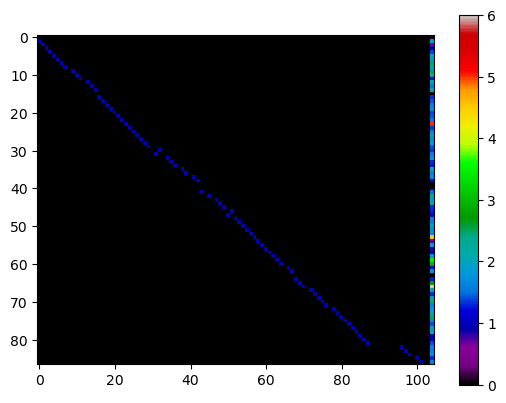

In [57]:
plt.imshow(mat, cmap='nipy_spectral')
plt.colorbar()

In [58]:
files

['20X_c0-DAPI_A1_Tile-10._probabilities.npy',
 '20X_c0-DAPI_A1_Tile-110._probabilities.npy',
 '20X_c0-DAPI_A1_Tile-130._probabilities.npy',
 '20X_c0-DAPI_A1_Tile-150._probabilities.npy',
 '20X_c0-DAPI_A1_Tile-170._probabilities.npy',
 '20X_c0-DAPI_A1_Tile-190._probabilities.npy',
 '20X_c0-DAPI_A1_Tile-30._probabilities.npy',
 '20X_c0-DAPI_A1_Tile-50._probabilities.npy',
 '20X_c0-DAPI_A1_Tile-70._probabilities.npy',
 '20X_c0-DAPI_A1_Tile-90._probabilities.npy',
 'C2-20X_c0-DAPI-GFP_A1_Tile-17._probabilities.npy',
 'C2-20X_c0-DAPI-GFP_A1_Tile-5._probabilities.npy',
 'C2-20X_c0-DAPI-GFP_A2_Tile-5._probabilities.npy',
 'C2-20X_c0-DAPI-GFP_A3_Tile-6._probabilities.npy',
 'C2-20X_c0-DAPI-GFP_B1_Tile-8._probabilities.npy',
 'C2-20X_c0-DAPI-GFP_B2_Tile-20._probabilities.npy',
 'C2-20X_c0-DAPI-GFP_B3_Tile-10._probabilities.npy',
 'C2-20X_c0-DAPI-GFP_B3_Tile-16._probabilities.npy']

In [ ]:
for file in files:
    imid = file.split('.')[0]
    prob = np.load(DIRECTORY + OUTPUT_DIR + file)
    mn_pred = prob[0,:,:] > THRESHOLD
    mn_gt = mnds.read_micronuclei_masks(DIRECTORY, imid, SCALE_FACTOR)
    
    pi = skimage.morphology.label(mn_pred)
    gti = skimage.morphology.label(mn_gt)
    nb_overdetection, nb_underdetection, mean_IoU, IoUs = compare_two_labels(pi, gti, True)
    
    matches = IoUs > 0.1
    ratio = []
    for i in range(0, matches.shape[0]):
        if (True in matches[i,:]):
            idx = np.where(matches[i,:]==True)[0][0]
            label_gt = i + 1
            label_pred = idx + 1
            
            area_gt = np.sum(gti == label_gt)
            area_pred = np.sum(pi == label_pred)
            ratio.append(area_gt/area_pred)
        else:
            ratio.append(0)
    
    print(imid, matches.shape, len(np.unique(pi)))
    mat = np.column_stack((matches, ratio))
    IoU_filename = f'{DIRECTORY}{OUTPUT_DIR}{imid}._IoUs.npy'
    # np.save(IoU_filename, mat)

## Save 18 images of real size vs detected size scatter plots

In [5]:
filelist = os.listdir(DIRECTORY + OUTPUT_DIR)
IoU_files = [file for file in filelist if file.endswith('._IoUs.npy')]

In [8]:
print(len(IoU_files))

18


In [9]:
path = DIRECTORY + OUTPUT_DIR + IoU_files[0]
x = np.load(path)
print(x.shape)

(83, 103)


In [10]:
y = x[:,:-1] # remove last column
y.shape

(83, 102)

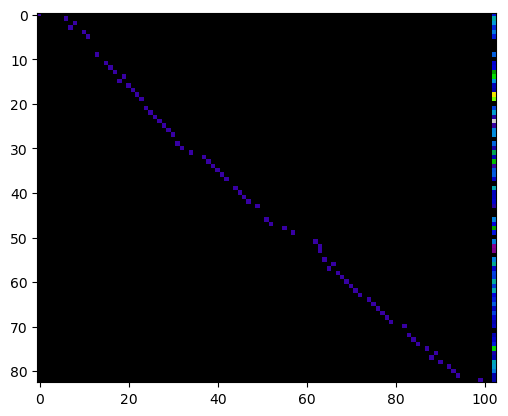

In [11]:
plt.imshow(x, cmap='nipy_spectral')
# plt.colorbar()

Aggregate the matches, convert to df where left column is 0/1s and right column is ratio, sort by ratio to see if there is a gap, happening on larger original sizes or smaller ones.

Remove the last column (which is ratio) for all _IoUs.npy files

In [12]:
path = DIRECTORY + OUTPUT_DIR + IoU_files[0]
matches = np.load(path)
matches = matches[:,:-1]
rows, cols = np.where(matches==True)
print(len(rows), len(cols))
print(rows[0:5])
print(cols[0:5])
print(matches[0,0])
print(matches[1,6])
print(matches[6,1])

71 71
[0 1 2 3 4]
[ 0  6  8  7 10]
1.0
1.0
0.0


In [83]:
# Verify if rows are the ground truth labels
imid = IoU_files[0].split('.')[0]
mn_gt = mnds.read_micronuclei_masks(DIRECTORY, imid, SCALE_FACTOR)
gti_example = skimage.morphology.label(mn_gt)
print(len(np.unique(gti_example)))
print(matches.shape) # it is 83 because the background is label 0, which we do not consider

84
(83, 102)


In [76]:
matches

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]])

In [79]:
1.0 == True

True

In [43]:
imid = IoU_files[0].split('.')[0]
mn_gt = mnds.read_micronuclei_masks(DIRECTORY, imid, SCALE_FACTOR)
gti = skimage.morphology.label(mn_gt)
area_gt = []

for i in range(1, len(np.unique(gti))):
    area = np.sum(gti==i)
    area_gt.append(area)
    
print(np.unique(gti))
print(0 in area_gt)
print(len(np.unique(gti)))
print(len(area_gt)) # don't calculate area of background, so it should be 1 shorter than the length of unique GT labels

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83]
False
84
83


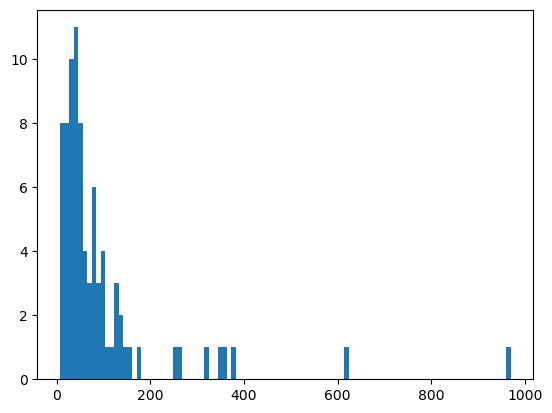

In [18]:
plt.hist(area_gt, bins=100)
plt.show()

In [20]:
THRESHOLD

0.5

## Scatter Plots

In [6]:
IoU_files

['20X_c0-DAPI_A1_Tile-10._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-110._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-130._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-150._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-170._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-190._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-30._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-50._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-70._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-90._IoUs.npy',
 'C2-20X_c0-DAPI-GFP_A1_Tile-17._IoUs.npy',
 'C2-20X_c0-DAPI-GFP_A1_Tile-5._IoUs.npy',
 'C2-20X_c0-DAPI-GFP_A2_Tile-5._IoUs.npy',
 'C2-20X_c0-DAPI-GFP_A3_Tile-6._IoUs.npy',
 'C2-20X_c0-DAPI-GFP_B1_Tile-8._IoUs.npy',
 'C2-20X_c0-DAPI-GFP_B2_Tile-20._IoUs.npy',
 'C2-20X_c0-DAPI-GFP_B3_Tile-10._IoUs.npy',
 'C2-20X_c0-DAPI-GFP_B3_Tile-16._IoUs.npy']

In [1]:
pilot = [file for file in IoU_files if not file.startswith('C2-')]
print(len(pilot)) # 10 expected

NameError: name 'IoU_files' is not defined

In [8]:
pilot

['20X_c0-DAPI_A1_Tile-10._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-110._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-130._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-150._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-170._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-190._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-30._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-50._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-70._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-90._IoUs.npy']

In [9]:
import pandas as pd

df_pilot = pd.DataFrame(columns = ['original_area', 'predicted_area', 'status'])

for i in range(len(pilot)):
    path = DIRECTORY + OUTPUT_DIR + pilot[i]
    matches = np.load(path)
    matches = matches[:,:-1] # remove last column which is ratio
    
    imid = pilot[i].split('.')[0]
    prob = np.load(f'{DIRECTORY}{OUTPUT_DIR}{imid}._probabilities.npy')
    mn_pred = prob[0,:,:] > THRESHOLD
    mn_gt = mnds.read_micronuclei_masks(DIRECTORY, imid, SCALE_FACTOR)
    
    pi = skimage.morphology.label(mn_pred)
    gti = skimage.morphology.label(mn_gt)
    
    original_area = []
    predicted_area = []
    status = [] # True/Flase
    
    for j in range(0, matches.shape[0]): # not detected should be 0 for predicted area
        if (True in matches[j,:]):
            idx = np.where(matches[j,:]==True)[0][0]
            label_gt = j + 1
            label_pred = idx + 1
            
            area_gt = np.sum(gti == label_gt)
            area_pred = np.sum(pi == label_pred)
            
            original_area.append(area_gt)
            predicted_area.append(area_pred)
            status.append('Detected') # detected
            
        else: # ground truth is not predicted by the model
            area_gt = np.sum(gti == label_gt)
            area_pred = 0
            
            original_area.append(area_gt)
            predicted_area.append(area_pred)
            status.append('Missed') # not detected
            
    df_single_image = pd.DataFrame({'original_area':original_area, 'predicted_area':predicted_area, 'status':status})
    df_pilot = pd.concat([df_pilot, df_single_image], ignore_index=True)

In [19]:
df_pilot

,original_area,predicted_area,status
0,363,224,Detected
1,11,4,Detected
2,19,8,Detected
3,60,36,Detected
4,39,20,Detected
...,...,...,...
958,56,52,Detected
959,227,136,Detected
960,25,24,Detected
961,25,0,Missed


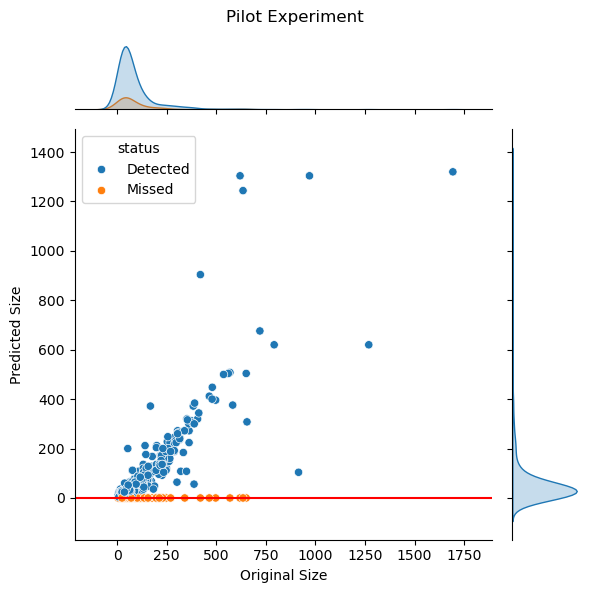

In [21]:
import seaborn as sns

pilot_figure = sns.jointplot(data=df_pilot, x='original_area', y='predicted_area', hue='status')
pilot_figure.figure.suptitle('Pilot Experiment')
plt.axhline(y=0, color='red')
plt.xlabel('Original Size')
plt.ylabel('Predicted Size')
plt.tight_layout()
plt.show()

In [10]:
screen = [file for file in IoU_files if file.startswith('C2-')]
print(len(screen)) # 8 expected
print(screen)

8
['C2-20X_c0-DAPI-GFP_A1_Tile-17._IoUs.npy', 'C2-20X_c0-DAPI-GFP_A1_Tile-5._IoUs.npy', 'C2-20X_c0-DAPI-GFP_A2_Tile-5._IoUs.npy', 'C2-20X_c0-DAPI-GFP_A3_Tile-6._IoUs.npy', 'C2-20X_c0-DAPI-GFP_B1_Tile-8._IoUs.npy', 'C2-20X_c0-DAPI-GFP_B2_Tile-20._IoUs.npy', 'C2-20X_c0-DAPI-GFP_B3_Tile-10._IoUs.npy', 'C2-20X_c0-DAPI-GFP_B3_Tile-16._IoUs.npy']


In [11]:
df_screen = pd.DataFrame(columns = ['original_area', 'predicted_area', 'status'])

for i in range(len(screen)):
    path = DIRECTORY + OUTPUT_DIR + screen[i]
    matches = np.load(path)
    matches = matches[:,:-1] # remove last column which is ratio
    
    imid = screen[i].split('.')[0]
    prob = np.load(f'{DIRECTORY}{OUTPUT_DIR}{imid}._probabilities.npy')
    mn_pred = prob[0,:,:] > THRESHOLD
    mn_gt = mnds.read_micronuclei_masks(DIRECTORY, imid, SCALE_FACTOR)
    
    pi = skimage.morphology.label(mn_pred)
    gti = skimage.morphology.label(mn_gt)
    
    original_area = []
    predicted_area = []
    status = [] # True/Flase
    
    for j in range(0, matches.shape[0]): # not detected should be 0 for predicted area
        if (True in matches[j,:]):
            idx = np.where(matches[j,:]==True)[0][0]
            label_gt = j + 1
            label_pred = idx + 1
            
            area_gt = np.sum(gti == label_gt)
            area_pred = np.sum(pi == label_pred)
            
            original_area.append(area_gt)
            predicted_area.append(area_pred)
            status.append('Detected') # detected
            
        else: # ground truth is not predicted by the model
            area_gt = np.sum(gti == label_gt)
            area_pred = 0
            
            original_area.append(area_gt)
            predicted_area.append(area_pred)
            status.append('Missed') # not detected
            
    df_single_image = pd.DataFrame({'original_area':original_area, 'predicted_area':predicted_area, 'status':status})
    df_screen = pd.concat([df_screen, df_single_image], ignore_index=True)

In [24]:
df_screen

,original_area,predicted_area,status
0,69,48,Detected
1,14,16,Detected
2,27,20,Detected
3,34,16,Detected
4,95,36,Detected
...,...,...,...
724,36,32,Detected
725,159,116,Detected
726,21,12,Detected
727,34,32,Detected


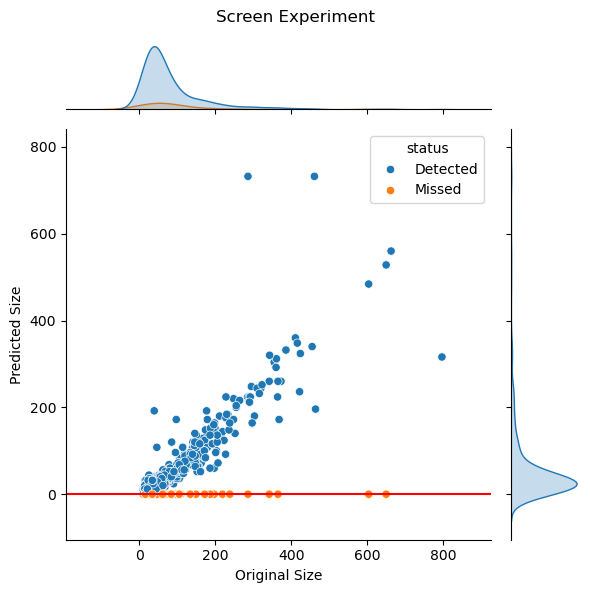

In [25]:
screen_figure = sns.jointplot(data=df_screen, x='original_area', y='predicted_area', hue='status')
screen_figure.figure.suptitle('Screen Experiment')
plt.axhline(y=0, color='red')
plt.xlabel('Original Size')
plt.ylabel('Predicted Size')
plt.tight_layout()
plt.show()

- Reproduce the distribution plots

/tmp/ipykernel_1714746/1568431131.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_screen, x='original_area', shade=True, hue='status')


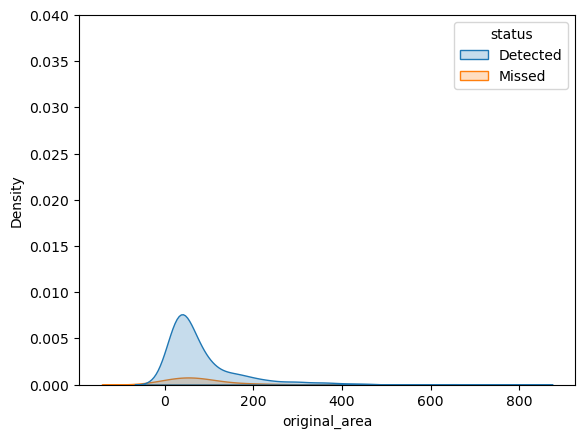

In [26]:
# Distribution of original size, including successfully detected and missed ones
sns.kdeplot(df_screen, x='original_area', shade=True, hue='status')
plt.ylim(0,0.04)
plt.show()

/tmp/ipykernel_1714746/4148200138.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_screen, x='predicted_area', shade=True)


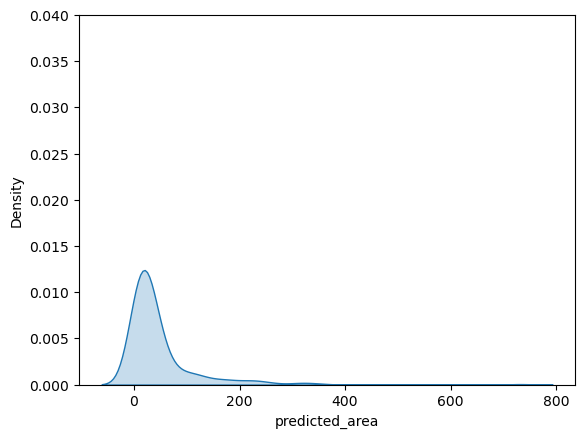

In [27]:
# Distribution of predicted size
sns.kdeplot(df_screen, x='predicted_area', shade=True)
plt.ylim(0,0.04)
plt.show()

# Statistical Test (Pilot)

Kolmogorov-Smirnov Test (K-S Test)

In [31]:
# Perform K-S test
df_pilot_detected = df_pilot[df_pilot['status']=='Detected']
df_pilot_missed = df_pilot[df_pilot['status']=='Missed']
stat, p_value = scipy.stats.ks_2samp(df_pilot_detected['original_area'], df_pilot_missed['original_area'])
print(f"K-S Test Statistic: {stat}, p-value: {p_value}")
print(df_pilot_detected.head())
print(df_pilot_missed.head())

K-S Test Statistic: 0.04546398635116089, p-value: 0.9195705592442959
  original_area predicted_area    status
0           363            224  Detected
1            11              4  Detected
2            19              8  Detected
3            60             36  Detected
4            39             20  Detected
   original_area predicted_area  status
6            105              0  Missed
7            105              0  Missed
8            105              0  Missed
10            15              0  Missed
20            39              0  Missed


In [32]:
# Perform K-S test
df_screen_detected = df_screen[df_screen['status']=='Detected']
df_screen_missed = df_screen[df_screen['status']=='Missed']
stat, p_value = scipy.stats.ks_2samp(df_screen_detected['original_area'], df_screen_missed['original_area'])
print(f"K-S Test Statistic: {stat}, p-value: {p_value}")
print(df_screen_detected.head())
print(df_screen_missed.head())

K-S Test Statistic: 0.10646717537995838, p-value: 0.25642888499811284
  original_area predicted_area    status
0            69             48  Detected
1            14             16  Detected
2            27             20  Detected
3            34             16  Detected
4            95             36  Detected
   original_area predicted_area  status
17            37              0  Missed
20            24              0  Missed
32            74              0  Missed
38            72              0  Missed
49            43              0  Missed


# Statistical Test (Screen)

# Aggregate matches, and sort by original size

In [65]:
matches = np.load(DIRECTORY + OUTPUT_DIR + IoU_files[0])
print(matches.shape)
ratio = matches[:,-1]
detection_match = np.sum(matches[:,:-1], axis=1)
df_match = pd.DataFrame({'detection':detection_match, 'ratio':ratio})
df_match = df_match.sort_values(by=['ratio'], ascending=False)
df_match

(83, 103)


,detection,ratio
24,1.0,7.750000
18,1.0,5.500000
19,1.0,4.875000
14,1.0,4.291667
75,1.0,4.200000
...,...,...
38,0.0,0.000000
45,0.0,0.000000
20,0.0,0.000000
10,0.0,0.000000


In [67]:
area_gt = []
imid = IoU_files[0].split('.')[0]
mn_gt = mnds.read_micronuclei_masks(DIRECTORY, imid, SCALE_FACTOR)
gti= skimage.morphology.label(mn_gt)

for i in range(matches.shape[0]):
    label_gt = i + 1
    area = np.sum(gti==label_gt)
    area_gt.append(area)

In [85]:
matches = np.load(DIRECTORY + OUTPUT_DIR + IoU_files[0])
matches = matches[:,:-1]

df = pd.DataFrame({'detection':np.sum(matches, axis=1), 'ground_truth_area':area_gt})
df = df.sort_values(by=['ground_truth_area'], ascending=False, ignore_index=True)
df.head()

,detection,ground_truth_area
0,1.0,970
1,1.0,620
2,1.0,376
3,1.0,363
4,1.0,352


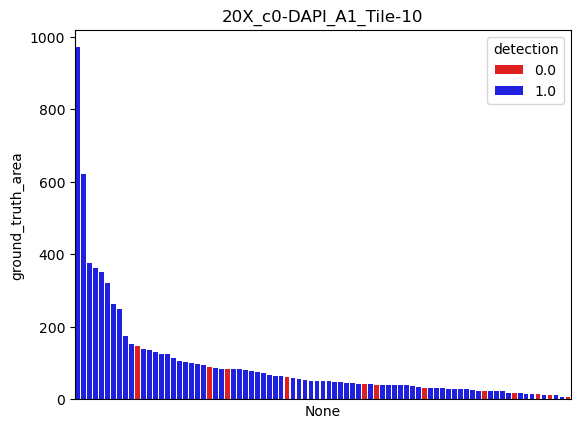

In [86]:
sns.barplot(data=df, x=df.index, y='ground_truth_area', hue='detection', palette={0: "red", 1: "blue"})
plt.title(IoU_files[0].split('.')[0])
plt.xticks([])
plt.show()

In [14]:
3 % 3

0

In [20]:
for i in range(len(IoU_files)):
    row = i // 3
    col = (i % 3)
    print(row, col)

0 0
0 1
0 2
1 0
1 1
1 2
2 0
2 1
2 2
3 0
3 1
3 2
4 0
4 1
4 2
5 0
5 1
5 2


In [25]:
len(IoU_files)

18

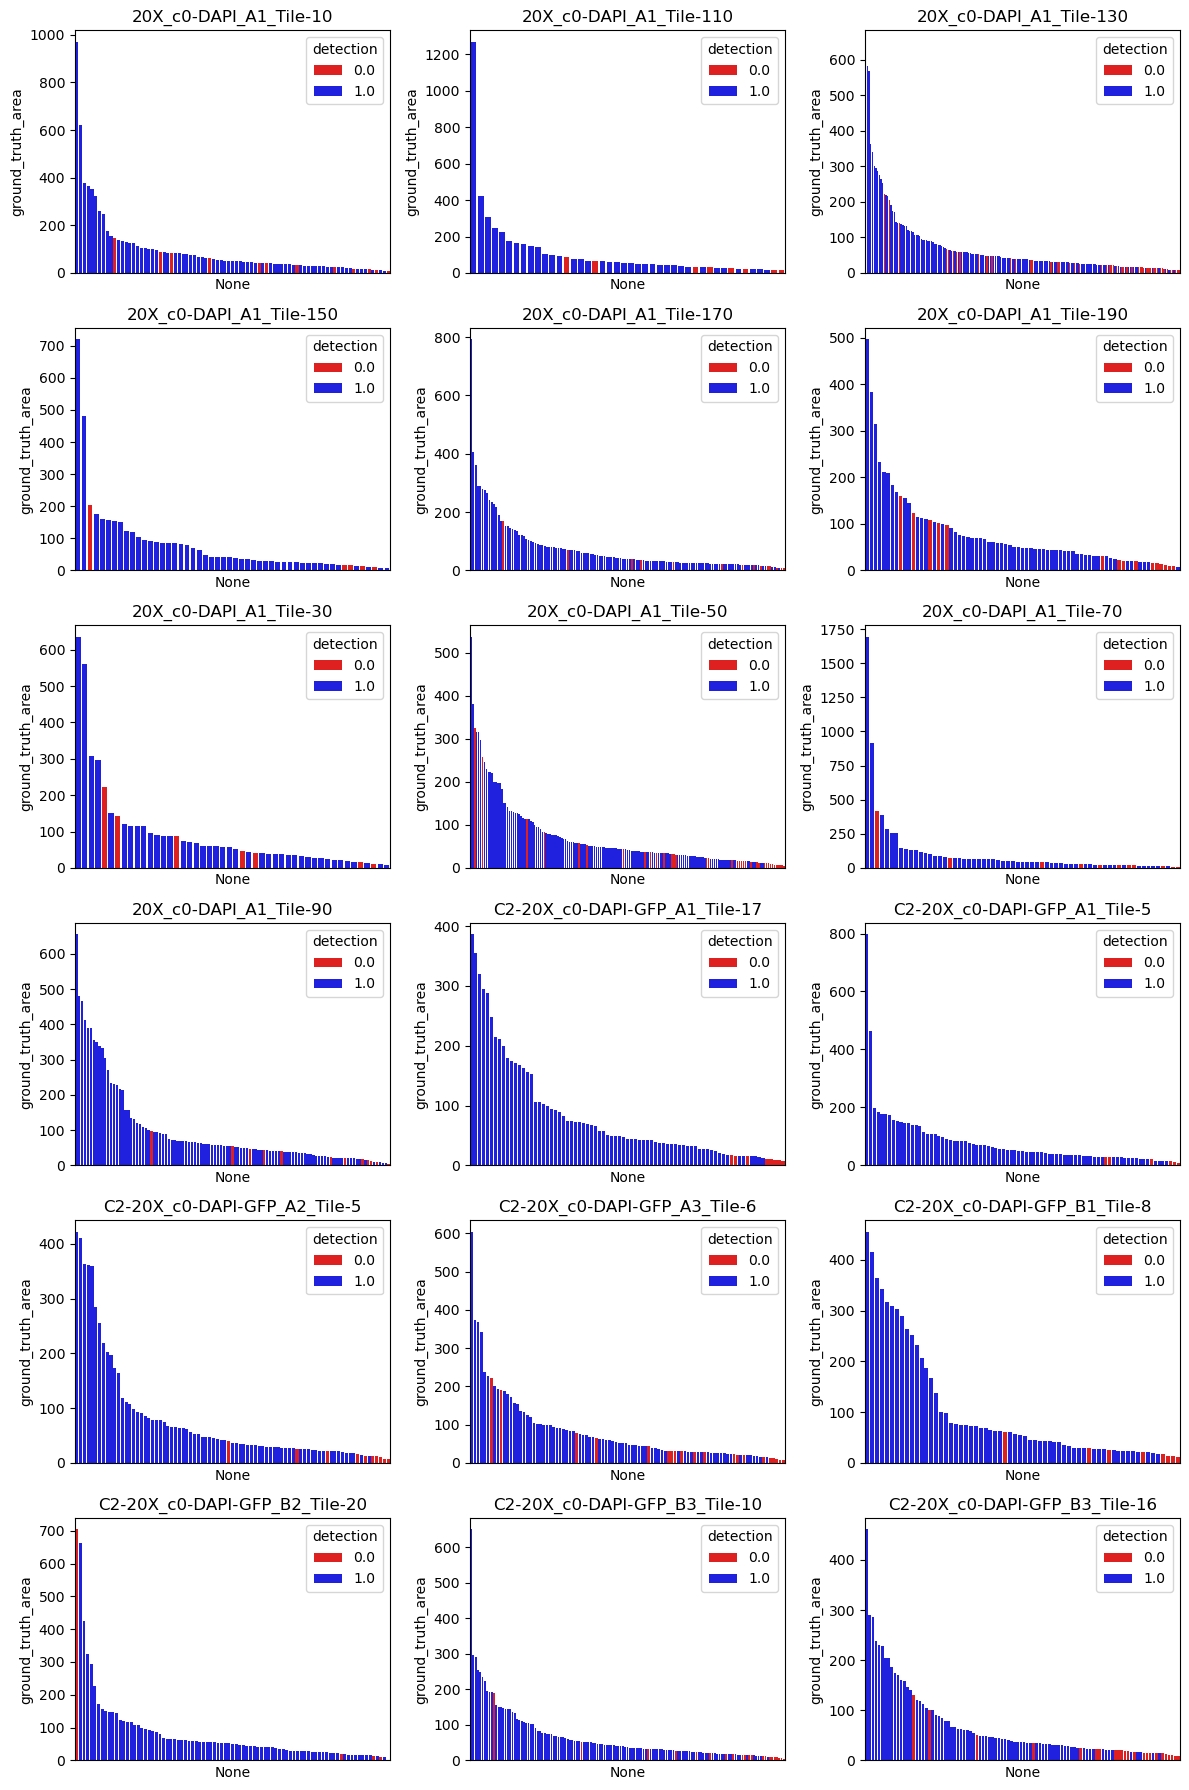

In [26]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import skimage.morphology  # Make sure to import this if you are using it

# Initialize the figure and axes
figs, ax = plt.subplots(6, 3, figsize=(12, 18))  # Adjust the figsize if needed

for i in range(len(IoU_files)):
    imid = IoU_files[i].split('.')[0]
    
    area_gt = []
    mn_gt = mnds.read_micronuclei_masks(DIRECTORY, imid, SCALE_FACTOR)
    gti = skimage.morphology.label(mn_gt)

    matches = np.load(DIRECTORY + OUTPUT_DIR + IoU_files[i])  # Use IoU_files[i] for the current file
    matches = matches[:, :-1]  # Remove ratio column
    for j in range(matches.shape[0]):
        label_gt = j + 1
        area = np.sum(gti == label_gt)
        area_gt.append(area)
        
    row = i // 3
    col = i % 3
    df = pd.DataFrame({'detection': np.sum(matches, axis=1), 'ground_truth_area': area_gt})
    df = df.sort_values(by=['ground_truth_area'], ascending=False, ignore_index=True)
    
    sns.barplot(
        data=df, 
        x=df.index, 
        y='ground_truth_area', 
        hue='detection', 
        palette={0: "red", 1: "blue"},
        ax=ax[row, col]
    )
    ax[row, col].set_title(imid)  # Set title for the specific subplot
    ax[row, col].set_xticks([])  # Turn off x ticks

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()


# Approximate Gaussian Distribution

In [13]:
np.mean(df_pilot['original_area'])

91.56593977154725

In [15]:
mu, sigma = scipy.stats.norm.fit(df_pilot['original_area'].to_list())

print(f"Mean (mu): {mu}")
print(f"Standard Deviation (sigma): {sigma}")

Mean (mu): 91.56593977154725
Standard Deviation (sigma): 128.84358473730458


In [38]:
y, x = np.random.normal(loc=256, scale=5, size=2)
print(y, x)

259.64297068475275 260.85621657618196


In [39]:
y, x = int(y), int(x)
print(y,x)

259 260
